# 02 — Classical Baselines

Trains and evaluates three classical models at all 5 prediction horizons:
- Model 0: Majority Class Baseline
- Model 1: Logistic Regression (class-weighted)
- Model 2: XGBoost (grid search, engineered features)

Ablations:
- Ablation A: XGBoost raw 40 features vs. raw + 13 engineered features
- Ablation B: Logistic Regression with vs. without class_weight='balanced'

Results saved to `results/classical_results.pkl` for use in notebook 04.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import sys, pickle

PROJECT_ROOT = os.path.expanduser('~/CS372/deeplob-midprice-prediction')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from src.data_loader import load_raw, extract_features_labels, temporal_split
from src.features import add_engineered_features
from src.models.baseline import MajorityClassifier
from src.models.logistic import LogisticModel
from src.models.xgboost_model import XGBoostModel
from src.evaluate import compute_metrics, build_results_table

RESULTS = os.path.join(PROJECT_ROOT, 'results')
DATA    = os.path.join(PROJECT_ROOT, 'data', 'raw')
os.makedirs(RESULTS, exist_ok=True)

HORIZONS = [1, 2, 3, 5, 10]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Load data

In [2]:
train_df = load_raw(os.path.join(DATA, 'FI2010_train.csv'))
test_df  = load_raw(os.path.join(DATA, 'FI2010_test.csv'))

X_all, Y_all   = extract_features_labels(train_df)
X_test, Y_test = extract_features_labels(test_df)

X_train, Y_train, X_val, Y_val = temporal_split(X_all, Y_all)

X_train_eng = add_engineered_features(X_train)
X_val_eng   = add_engineered_features(X_val)
X_test_eng  = add_engineered_features(X_test)

print(f'Train:      {X_train.shape}   engineered: {X_train_eng.shape}')
print(f'Val:        {X_val.shape}     engineered: {X_val_eng.shape}')
print(f'Test:       {X_test.shape}    engineered: {X_test_eng.shape}')

Train:      (308040, 40)   engineered: (308040, 53)
Val:        (54360, 40)     engineered: (54360, 53)
Test:       (31937, 40)    engineered: (31937, 53)


## 2. Majority Class Baseline

Always predicts the most frequent class (stationary = 1) seen in training. Zero parameters. The absolute performance floor.

In [3]:
majority_results = []

for h_idx, k in enumerate(HORIZONS):
    clf = MajorityClassifier().fit(X_train, Y_train[:, h_idx])
    preds = clf.predict(X_test)
    metrics = compute_metrics(Y_test[:, h_idx], preds)
    majority_results.append(metrics)
    print(f'  k={k:>2}  majority_class={clf.majority_class}  '
          f'weighted_F1={metrics["weighted_f1"]:.4f}  '
          f'kappa={metrics["cohen_kappa"]:.4f}')

print('\nPer-class F1 at k=1 [down, stat, up]:', [f'{v:.3f}' for v in majority_results[0]['per_class_f1']])

  k= 1  majority_class=1  weighted_F1=0.5352  kappa=0.0000
  k= 2  majority_class=1  weighted_F1=0.4131  kappa=0.0000
  k= 3  majority_class=1  weighted_F1=0.3389  kappa=0.0000
  k= 5  majority_class=1  weighted_F1=0.2341  kappa=0.0000
  k=10  majority_class=0  weighted_F1=0.2123  kappa=0.0000

Per-class F1 at k=1 [down, stat, up]: ['0.000', '0.801', '0.000']


## 3. Logistic Regression

Linear classifier on raw 40 features with `class_weight='balanced'`. Trained separately per horizon.

In [4]:
lr_results = []

for h_idx, k in enumerate(HORIZONS):
    print(f'  Training LR k={k}...', end=' ', flush=True)
    model = LogisticModel().fit(X_train, Y_train[:, h_idx])
    preds = model.predict(X_test)
    metrics = compute_metrics(Y_test[:, h_idx], preds)
    lr_results.append(metrics)
    print(f'weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')

  Training LR k=1... weighted_F1=0.5297  kappa=0.0957
  Training LR k=2... weighted_F1=0.4779  kappa=0.0894
  Training LR k=3... weighted_F1=0.4498  kappa=0.1115
  Training LR k=5... weighted_F1=0.4057  kappa=0.1083
  Training LR k=10... weighted_F1=0.3677  kappa=0.1153


## 4. XGBoost with Grid Search

Grid search over 3 hyperparameter configs using validation weighted-F1. Final model uses raw + engineered features.

In [5]:
xgb_results = []
xgb_best_configs = []

for h_idx, k in enumerate(HORIZONS):
    print(f'\n--- XGBoost k={k} ---')
    model = XGBoostModel()
    best_cfg = model.grid_search(
        X_train_eng, Y_train[:, h_idx],
        X_val_eng,   Y_val[:, h_idx],
        verbose=True
    )
    model.fit(X_train_eng, Y_train[:, h_idx])
    preds = model.predict(X_test_eng)
    metrics = compute_metrics(Y_test[:, h_idx], preds)
    xgb_results.append(metrics)
    xgb_best_configs.append(best_cfg)
    print(f'  TEST  weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')


--- XGBoost k=1 ---
  config={'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  val_F1=0.5963
  config={'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}  val_F1=0.6048
  config={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01}  val_F1=0.5957
  → best config: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}  (val_F1=0.6048)
  TEST  weighted_F1=0.5733  kappa=0.0787

--- XGBoost k=2 ---
  config={'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  val_F1=0.5114
  config={'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}  val_F1=0.5345
  config={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01}  val_F1=0.5142
  → best config: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}  (val_F1=0.5345)
  TEST  weighted_F1=0.4895  kappa=0.1025

--- XGBoost k=3 ---
  config={'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  val_F1=0.4799
  config={'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}  va

## 5. Classical Models Summary Table

In [6]:
table = build_results_table({'Majority': majority_results, 'Logistic': lr_results, 'XGBoost': xgb_results})
print('Weighted F1 on test set:')
print(table.to_string(float_format='{:.4f}'.format))

Weighted F1 on test set:
            k=1    k=2    k=3    k=5   k=10
Majority 0.5352 0.4131 0.3389 0.2341 0.2123
Logistic 0.5297 0.4779 0.4498 0.4057 0.3677
XGBoost  0.5733 0.4895 0.4811 0.4623 0.4169


## 6. Ablation A — Feature Engineering Impact

XGBoost on raw 40 features vs. raw + 13 engineered (53 total). Same winning config used for both.

In [7]:
ablation_a_raw = []
ablation_a_eng = xgb_results  # already computed above with engineered features

for h_idx, k in enumerate(HORIZONS):
    m_raw = XGBoostModel()
    m_raw.fit(X_train, Y_train[:, h_idx], config=xgb_best_configs[h_idx])
    ablation_a_raw.append(compute_metrics(Y_test[:, h_idx], m_raw.predict(X_test)))

tbl_a = build_results_table({
    'XGB raw (40)':         ablation_a_raw,
    'XGB engineered (53)':  ablation_a_eng,
})
print('Ablation A — Feature Engineering (weighted F1):')
print(tbl_a.to_string(float_format='{:.4f}'.format))
delta_a = tbl_a.loc['XGB engineered (53)'] - tbl_a.loc['XGB raw (40)']
print('\nDelta (engineered − raw):')
print(delta_a.to_string(float_format='{:+.4f}'.format))

Ablation A — Feature Engineering (weighted F1):
                       k=1    k=2    k=3    k=5   k=10
XGB raw (40)        0.5790 0.4910 0.4696 0.4414 0.3994
XGB engineered (53) 0.5733 0.4895 0.4811 0.4623 0.4169

Delta (engineered − raw):
k=1    -0.0057
k=2    -0.0014
k=3    +0.0116
k=5    +0.0209
k=10   +0.0175


## 7. Ablation B — Class Weighting Impact

Logistic Regression with vs. without `class_weight='balanced'`.

In [9]:
ablation_b_balanced   = lr_results
ablation_b_unweighted = []

for h_idx, k in enumerate(HORIZONS):
    print(f'  LR unweighted k={k}...', end=' ', flush=True)
    clf = LogisticRegression(
        class_weight=None, C=1.0, max_iter=1000,
        solver='lbfgs'
    ).fit(X_train, Y_train[:, h_idx])
    preds = clf.predict(X_test)
    ablation_b_unweighted.append(compute_metrics(Y_test[:, h_idx], preds))
    print('done')

tbl_b = build_results_table({
    'LR unweighted':     ablation_b_unweighted,
    'LR class-balanced': ablation_b_balanced,
})
print('\nAblation B — Class Weighting (weighted F1):')
print(tbl_b.to_string(float_format='{:.4f}'.format))
delta_b = tbl_b.loc['LR class-balanced'] - tbl_b.loc['LR unweighted']
print('\nDelta (balanced − unweighted):')
print(delta_b.to_string(float_format='{:+.4f}'.format))

  LR unweighted k=1... done
  LR unweighted k=2... done
  LR unweighted k=3... done
  LR unweighted k=5... done
  LR unweighted k=10... done

Ablation B — Class Weighting (weighted F1):
                     k=1    k=2    k=3    k=5   k=10
LR unweighted     0.5354 0.4165 0.3744 0.3935 0.3610
LR class-balanced 0.5297 0.4779 0.4498 0.4057 0.3677

Delta (balanced − unweighted):
k=1    -0.0057
k=2    +0.0614
k=3    +0.0755
k=5    +0.0122
k=10   +0.0067


## 8. Ablation bar charts

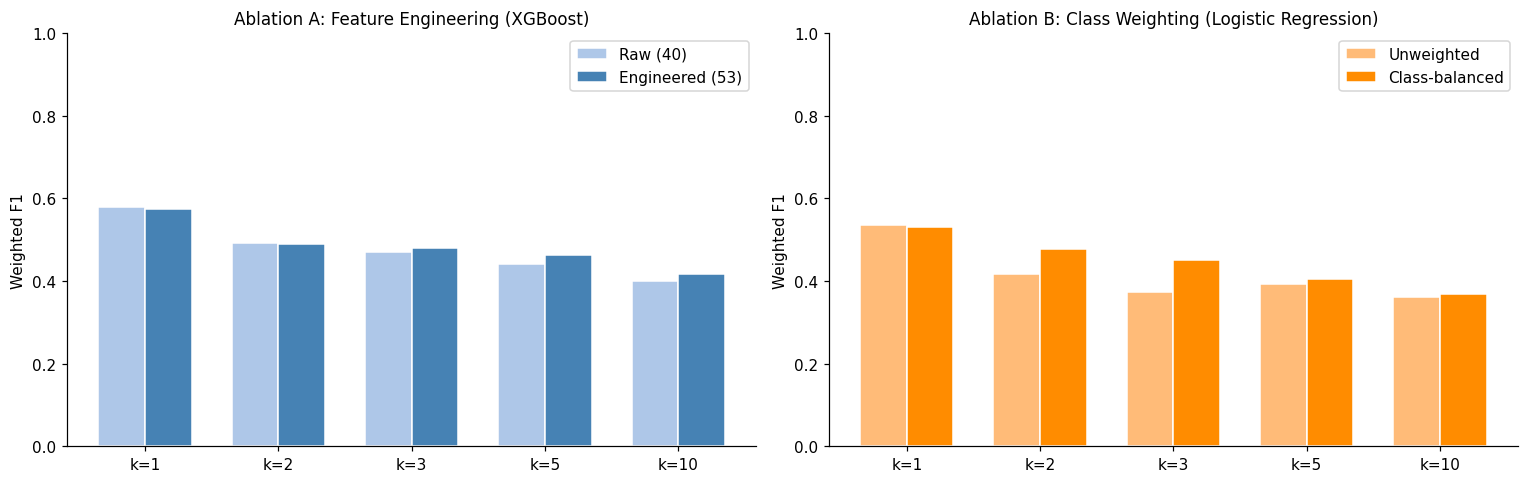

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(HORIZONS))
xlabels = [f'k={k}' for k in HORIZONS]
w = 0.35

ax = axes[0]
ax.bar(x - w/2, [r['weighted_f1'] for r in ablation_a_raw], w, label='Raw (40)', color='#aec7e8', edgecolor='white')
ax.bar(x + w/2, [r['weighted_f1'] for r in ablation_a_eng], w, label='Engineered (53)', color='steelblue', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylabel('Weighted F1'); ax.set_ylim(0, 1)
ax.set_title('Ablation A: Feature Engineering (XGBoost)', fontsize=11)
ax.legend()

ax = axes[1]
ax.bar(x - w/2, [r['weighted_f1'] for r in ablation_b_unweighted], w, label='Unweighted', color='#ffbb78', edgecolor='white')
ax.bar(x + w/2, [r['weighted_f1'] for r in ablation_b_balanced],   w, label='Class-balanced', color='darkorange', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylabel('Weighted F1'); ax.set_ylim(0, 1)
ax.set_title('Ablation B: Class Weighting (Logistic Regression)', fontsize=11)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'ablations_classical.png'), bbox_inches='tight')
plt.show()

## 9. Save results for notebook 04

In [11]:
classical_results = {
    'majority':         majority_results,
    'logistic':         lr_results,
    'xgboost':          xgb_results,
    'xgb_best_configs': xgb_best_configs,
    'ablation_a_raw':   ablation_a_raw,
    'ablation_a_eng':   ablation_a_eng,
    'ablation_b_unw':   ablation_b_unweighted,
    'ablation_b_bal':   ablation_b_balanced,
}

with open(os.path.join(RESULTS, 'classical_results.pkl'), 'wb') as f:
    pickle.dump(classical_results, f)

print('Saved to results/classical_results.pkl')
print('\nFinal summary (weighted F1):')
print(build_results_table({'Majority': majority_results, 'Logistic': lr_results, 'XGBoost': xgb_results})
      .to_string(float_format='{:.4f}'.format))

Saved to results/classical_results.pkl

Final summary (weighted F1):
            k=1    k=2    k=3    k=5   k=10
Majority 0.5352 0.4131 0.3389 0.2341 0.2123
Logistic 0.5297 0.4779 0.4498 0.4057 0.3677
XGBoost  0.5733 0.4895 0.4811 0.4623 0.4169
